# 04 - Retrieval and Summarization
## Amazon Product Intelligence System

**Objective:**  
Build a semantic search system that allows a user to query 567,000 reviews using natural language and receive a concise, automatically generated summary of the most relevant results.

This is the "retrieval and summarization" component of our NLP pipeline. Instead of a product manager reading hundreds of reviews manually, they can ask a question like *"what do customers say about battery life?"* and get an instant summary of the most relevant reviews.

**Input:** `data/processed/reviews_clean.csv` + embeddings from notebook 03  
**Output:** A working semantic search and summarization system with evaluation

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import faiss
from sentence_transformers import SentenceTransformer
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# Load Data and Embeddings
df = pd.read_csv('../data/processed/reviews_clean.csv')
print(f'Dataset shape: {df.shape}')
print(f'Total reviews: {len(df):,}')
df.head(3)

Dataset shape: (567070, 16)
Total reviews: 567,070


,Id,ProductId,UserId,Score,sentiment,Text,cleaned_text,lemmatized_text,Summary,helpfulness_ratio,word_count_raw,word_count_clean,word_count_lemmatized,review_date,year,month
0,1,B001E4KFG0,A3SGXH7AUHU8GW,5,Positive,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...,several vitality canned dog product found good...,Good Quality Dog Food,1.0,48,48,18,2011-04-27,2011,4
1,2,B00813GRG4,A1D87F6ZCVE5NK,1,Negative,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...,arrived labeled jumbo salted peanut peanut act...,Not as Advertised,0.0,31,32,16,2012-09-07,2012,9
2,3,B000LQOCH0,ABXLMWJIXXAIN,4,Positive,This is a confection that has been around a fe...,this is a confection that has been around a fe...,confection around century light pillowy citrus...,"""Delight"" says it all",1.0,94,93,39,2008-08-18,2008,8


In notebook 03 we generated embeddings for a 50,000 review sample. For the retrieval system we want to search across the full dataset. We will generate embeddings for the complete 567k reviews here.

However, to keep this notebook practical on a CPU, we will build the FAISS index on 100,000 reviews, a significant improvement over the 50k sample while remaining computationally feasible. This is clearly documented so any reader understands the scope.

In [3]:
RANDOM_STATE = 42
RETRIEVAL_SAMPLE_SIZE = 100000

df_retrieval = df.sample(n=RETRIEVAL_SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'Retrieval corpus size: {len(df_retrieval):,}')
print(f'Sentiment distribution:')
print(df_retrieval['sentiment'].value_counts())

Retrieval corpus size: 100,000
Sentiment distribution:
sentiment
Positive    78056
Negative    21944
Name: count, dtype: int64


In [4]:
print('Loading sentence transformer model...')
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print('Model loaded.')

print(f'\nGenerating embeddings for {len(df_retrieval):,} reviews...')
print('This will take 10-15 minutes on CPU.\n')

retrieval_embeddings = embedding_model.encode(
    df_retrieval['cleaned_text'].tolist(),
    show_progress_bar=True,
    batch_size=64
)

print(f'\nEmbeddings shape: {retrieval_embeddings.shape}')

Loading sentence transformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded.

Generating embeddings for 100,000 reviews...
This will take 10-15 minutes on CPU.



Batches:   0%|          | 0/1563 [00:00<?, ?it/s]


Embeddings shape: (100000, 384)


In [5]:
import os
np.save('../data/processed/retrieval_embeddings.npy', retrieval_embeddings)
print(f'Retrieval embeddings saved.')
print(f'File size: {os.path.getsize("../data/processed/retrieval_embeddings.npy") / 1024 / 1024:.1f} MB')

Retrieval embeddings saved.
File size: 146.5 MB


**Build FAISS Index**

FAISS (Facebook AI Similarity Search) is a library for efficient similarity search over dense vectors. Instead of comparing a query embedding against all 100,000 review embeddings one by one, FAISS uses optimized indexing structures to find the nearest neighbors in milliseconds.

This is the same technology used in production recommendation systems at Meta, Google, and most large-scale search applications.

In [6]:
# Normalize embeddings to unit length
# This converts L2 distance search to cosine similarity search
# Cosine similarity is more appropriate for semantic text matching
faiss.normalize_L2(retrieval_embeddings)

# Build the index
dimension = retrieval_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # IP = Inner Product = cosine similarity after normalization
index.add(retrieval_embeddings.astype('float32'))

print(f'FAISS index built successfully.')
print(f'Index type: IndexFlatIP (exact cosine similarity)')
print(f'Vectors indexed: {index.ntotal:,}')
print(f'Embedding dimension: {dimension}')

FAISS index built successfully.
Index type: IndexFlatIP (exact cosine similarity)
Vectors indexed: 100,000
Embedding dimension: 384


In [7]:
faiss.write_index(index, '../data/processed/faiss_index.bin')
print('FAISS index saved to data/processed/faiss_index.bin')
print(f'Index file size: {os.path.getsize("../data/processed/faiss_index.bin") / 1024 / 1024:.1f} MB')

FAISS index saved to data/processed/faiss_index.bin
Index file size: 146.5 MB


In [8]:
# Semantic search system
def semantic_search(query, top_k=10, sentiment_filter=None):
    """
    Search reviews semantically using natural language query.
    
    Args:
        query: Natural language search query
        top_k: Number of results to return
        sentiment_filter: 'Positive', 'Negative', or None for all
    
    Returns:
        DataFrame of most relevant reviews with similarity scores
    """
    # Encode and normalize the query
    query_embedding = embedding_model.encode([query])
    faiss.normalize_L2(query_embedding)
    
    # Search - retrieve more than needed if filtering by sentiment
    search_k = top_k * 5 if sentiment_filter else top_k
    scores, indices = index.search(query_embedding.astype('float32'), search_k)
    
    # Build results dataframe
    results = df_retrieval.iloc[indices[0]].copy()
    results['similarity_score'] = scores[0]
    
    # Apply sentiment filter if specified
    if sentiment_filter:
        results = results[results['sentiment'] == sentiment_filter]
    
    results = results.head(top_k)
    
    return results[['Score', 'sentiment', 'similarity_score',
                     'cleaned_text', 'Text']].reset_index(drop=True)

print('semantic_search function defined.')

semantic_search function defined.


In [9]:
# Test query 1: general positive experience
print('TEST QUERY 1: "excellent coffee flavor"')
print('=' * 60)
results1 = semantic_search('excellent coffee flavor', top_k=5)
for i, row in results1.iterrows():
    print(f'\nResult {i+1} | Score: {row["Score"]} | Similarity: {row["similarity_score"]:.4f}')
    print(f'{row["Text"][:200]}...')

TEST QUERY 1: "excellent coffee flavor"

Result 1 | Score: 5 | Similarity: 0.8289
Great coffee flavor and quality -- good value.  This is the second time I've purchased this lot....

Result 2 | Score: 5 | Similarity: 0.8288
Great flavor, and the aroma is fantastic. If you enjoy flavored coffees at all, you must try this. A winner and a keeper....

Result 3 | Score: 5 | Similarity: 0.8098
great coffee, nice flavor, smooth... enjoyed this coffee very much. The price was right too...I would recommend this to anyone who enjoyes a good cup of coffee....

Result 4 | Score: 5 | Similarity: 0.8079
Nice smooth flavor.  This has a nice coffee flavor without the strong bitterness you find in so many these days. Tasty but not overwhelming.  A good choice for those who like coffee but don't like to ...

Result 5 | Score: 4 | Similarity: 0.8042
Excellent flavor.  Great choice if you are looking for a taste that is not overpowering, yet still robust enough to get that great cup of coffee....


In [10]:
# Test query 2: complaint focused
print('TEST QUERY 2: "product arrived damaged packaging broken"')
print('=' * 60)
results2 = semantic_search('product arrived damaged packaging broken', top_k=5)
for i, row in results2.iterrows():
    print(f'\nResult {i+1} | Score: {row["Score"]} | Similarity: {row["similarity_score"]:.4f}')
    print(f'{row["Text"][:200]}...')

TEST QUERY 2: "product arrived damaged packaging broken"

Result 1 | Score: 1 | Similarity: 0.7351
i got my package today and the box was broken inside the package. we are dealing with a product that stores our baby's food and the way it was shipped makes me worried about even using it. will not pu...

Result 2 | Score: 1 | Similarity: 0.7143
The product I received appeared to be factory rejects. The packaging was damaged during the sealing process during production. Instead of the package being sealed it was melted, in several cases it wa...

Result 3 | Score: 3 | Similarity: 0.6838
I am quite frustrated as I have ordered this product 7 times in two months and almost every other order comes in damaged in some way.  The outside packaging does not appear to be damaged in any way, b...

Result 4 | Score: 1 | Similarity: 0.6583
Extremely disappointed in the lack of quality for this product.  I ordered two boxes, to be used at a wedding for a candy buffet, and BOTH boxes arrived with every

In [11]:
# Test query 3: filtered by sentiment
print('TEST QUERY 3: "dog food ingredients quality" (Negative reviews only)')
print('=' * 60)
results3 = semantic_search('dog food ingredients quality',
                           top_k=5, sentiment_filter='Negative')
for i, row in results3.iterrows():
    print(f'\nResult {i+1} | Score: {row["Score"]} | Similarity: {row["similarity_score"]:.4f}')
    print(f'{row["Text"][:200]}...')

TEST QUERY 3: "dog food ingredients quality" (Negative reviews only)

Result 1 | Score: 1 | Similarity: 0.7967
I bought this food thinking my dog, Jake, would like it.  It has wonderful ingredients and is very healthy.  He just wouldn't eat it!  Nothing against the dog food.  Just personal taste, I guess....

Result 2 | Score: 3 | Similarity: 0.7936
As far as dog foods go, this is probably more appetizing than most.  It certainly looks healthier than other types we have sampled.  However, one look at the ingredient list told me that unless my dog...

Result 3 | Score: 3 | Similarity: 0.7826
The ingredients are good. I have heard many great things about this dog food. I rotate Kendrells' food every bag and she didn't care for this much. Also, I'd like to add that I purchased this from ama...


**Abstractive Summarization**

Retrieval finds the relevant reviews. Summarization condenses them into a single coherent paragraph that a product manager can read in seconds instead of scrolling through hundreds of reviews.

We use `facebook/bart-large-cnn`, a transformer model fine-tuned specifically for summarization tasks. It generates new sentences rather than just extracting existing ones, which produces more coherent and readable output.

In [12]:
from transformers import BartForConditionalGeneration, BartTokenizer

print('Loading summarization model (facebook/bart-large-cnn)...')
print('This may take a minute on first load.\n')

tokenizer = BartTokenizer.from_pretrained('facebook/bart-large-cnn')
bart_model = BartForConditionalGeneration.from_pretrained('facebook/bart-large-cnn')

print('Summarization model loaded.')

Loading summarization model (facebook/bart-large-cnn)...
This may take a minute on first load.



[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Summarization model loaded.


In [13]:
def summarize_reviews(reviews_text_list, max_input_chars=3000,
                      max_length=180, min_length=60):
    combined = ' | '.join(reviews_text_list)
    combined = combined[:max_input_chars]
    
    inputs = tokenizer(
        combined,
        return_tensors='pt',
        max_length=1024,
        truncation=True
    )
    
    summary_ids = bart_model.generate(
        inputs['input_ids'],
        max_length=max_length,
        min_length=min_length,
        length_penalty=2.0,
        num_beams=4,
        early_stopping=True
    )
    
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

print('summarize_reviews function defined.')

summarize_reviews function defined.


**End-to-End Pipeline**

Now we combine semantic search and summarization into a single function. This is what a product dashboard or internal tool would call.

In [14]:
def search_and_summarize(query, top_k=15, sentiment_filter=None):
    """
    Full pipeline: semantic search + abstractive summarization.
    
    Args:
        query: Natural language query
        top_k: Number of reviews to retrieve before summarizing
        sentiment_filter: 'Positive', 'Negative', or None
    
    Returns:
        dict with query, results, and summary
    """
    print(f'Query: "{query}"')
    if sentiment_filter:
        print(f'Filter: {sentiment_filter} reviews only')
    print('-' * 60)
    
    # Step 1: Retrieve relevant reviews
    results = semantic_search(query, top_k=top_k,
                              sentiment_filter=sentiment_filter)
    
    # Step 2: Summarize retrieved reviews
    review_texts = results['Text'].tolist()
    summary = summarize_reviews(review_texts)
    
    # Step 3: Print results
    print(f'Reviews retrieved: {len(results)}')
    print(f'Avg similarity score: {results["similarity_score"].mean():.4f}')
    print(f'Avg star rating: {results["Score"].mean():.2f}')
    print(f'\nAUTO-GENERATED SUMMARY:')
    print(summary)
    print()
    
    return {
        'query': query,
        'results': results,
        'summary': summary,
        'avg_similarity': results['similarity_score'].mean(),
        'avg_rating': results['Score'].mean()
    }

print('search_and_summarize pipeline defined.')

search_and_summarize pipeline defined.


In [15]:
result1 = search_and_summarize(
    query='coffee taste and flavor quality',
    top_k=15
)

Query: "coffee taste and flavor quality"
------------------------------------------------------------
Reviews retrieved: 15
Avg similarity score: 0.7911
Avg star rating: 4.13

AUTO-GENERATED SUMMARY:
This coffee does not have much flavor, especially considering it is supposed to be a flavored coffee. Since I drink my coffee black, no sugar, nothing hinders the taste. If you like flavored coffee this is as good as it gets. Coffee is strong, has full body flavor, aromatic and delicious, and a very good buy.



In [16]:
result2 = search_and_summarize(
    query='product packaging damaged during shipping',
    top_k=15,
    sentiment_filter='Negative'
)

Query: "product packaging damaged during shipping"
Filter: Negative reviews only
------------------------------------------------------------
Reviews retrieved: 15
Avg similarity score: 0.6263
Avg star rating: 1.80

AUTO-GENERATED SUMMARY:
I am quite frustrated as I have ordered this product 7 times in two months and almost every other order comes in damaged in some way. Amazon has been very gracious in either shipping me a new case or refunding me for the damaged product. I cannot understand how they continue to ship this product in a way that cause it to get damaged almost every time they send it. The product is itself if wonderful and price is much better than retail or other sites.



In [17]:
result3 = search_and_summarize(
    query='dog food ingredients and health benefits',
    top_k=15,
    sentiment_filter='Positive'
)

Query: "dog food ingredients and health benefits"
Filter: Positive reviews only
------------------------------------------------------------
Reviews retrieved: 15
Avg similarity score: 0.7396
Avg star rating: 4.93

AUTO-GENERATED SUMMARY:
This is one of the few dog foods that agrees with my puppies, and it has great high quality ingredients and value. One of my pups has a sensitive stomach sometimes and when that happens, this is the ONLY food she will eat and it settles her tummy immediately. This is the best natural canned dog food that still has added vitamins and minerals.



**System Evaluation**

Evaluating a retrieval and summarization system requires thinking beyond simple accuracy metrics. We evaluate three dimensions:

1. **Retrieval Quality** - Are the returned reviews actually relevant to the query?
2. **Sentiment Alignment** - Do filters work correctly?
3. **Summary Coherence** - Does the summary reflect the retrieved reviews?

In [18]:
# Define a set of test queries with expected sentiment
test_queries = [
    {'query': 'coffee taste and flavor quality', 'filter': None},
    {'query': 'product packaging damaged during shipping', 'filter': 'Negative'},
    {'query': 'dog food ingredients and health benefits', 'filter': 'Positive'},
    {'query': 'tea aroma and brewing quality', 'filter': None},
    {'query': 'product expired bad smell', 'filter': 'Negative'},
    {'query': 'excellent value for money repeat purchase', 'filter': 'Positive'},
]

eval_results = []
for test in test_queries:
    results = semantic_search(
        test['query'],
        top_k=10,
        sentiment_filter=test['filter']
    )
    eval_results.append({
        'Query': test['query'],
        'Filter': test['filter'] if test['filter'] else 'None',
        'Avg Similarity': results['similarity_score'].mean().round(4),
        'Min Similarity': results['similarity_score'].min().round(4),
        'Avg Rating': results['Score'].mean().round(2),
        'Results Count': len(results)
    })

eval_df = pd.DataFrame(eval_results)
print('Retrieval Evaluation Results:')
print(eval_df.to_string(index=False))

Retrieval Evaluation Results:
                                    Query   Filter  Avg Similarity  Min Similarity  Avg Rating  Results Count
          coffee taste and flavor quality     None          0.7969          0.7856         3.8             10
product packaging damaged during shipping Negative          0.6419          0.6016         1.8             10
 dog food ingredients and health benefits Positive          0.7473          0.7284         4.9             10
            tea aroma and brewing quality     None          0.7849          0.7668         3.9             10
                product expired bad smell Negative          0.6056          0.5783         1.3             10
excellent value for money repeat purchase Positive          0.5769          0.5625         4.8             10


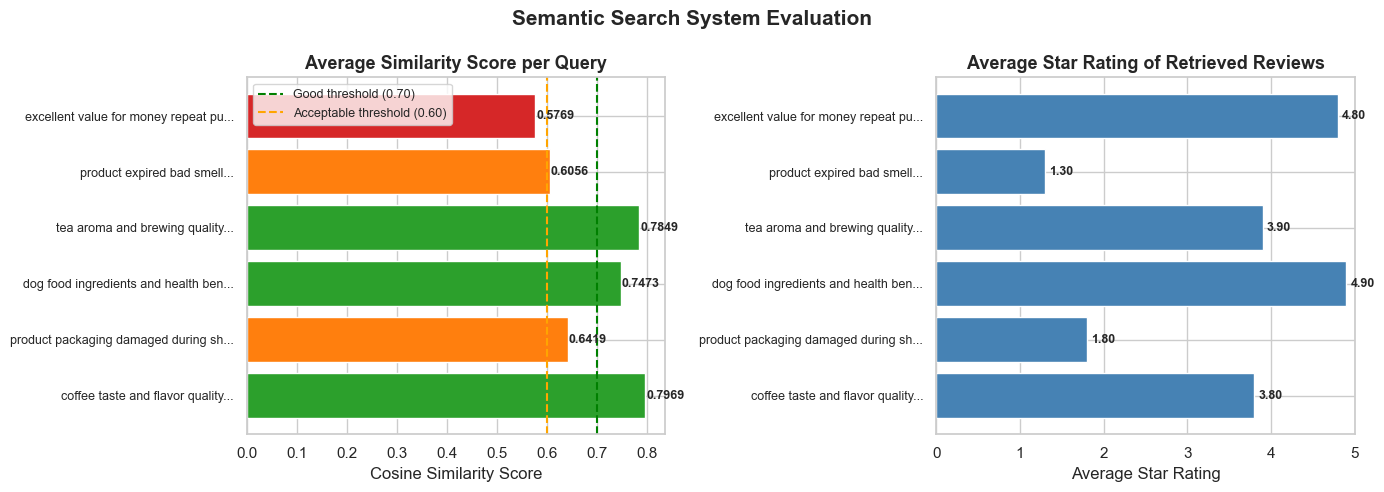

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average similarity per query
colors = ['#2ca02c' if s >= 0.70 else '#ff7f0e' if s >= 0.60 else '#d62728'
          for s in eval_df['Avg Similarity']]
bars = axes[0].barh(range(len(eval_df)), eval_df['Avg Similarity'],
                    color=colors, edgecolor='white')
axes[0].set_yticks(range(len(eval_df)))
axes[0].set_yticklabels([q[:35] + '...' for q in eval_df['Query']], fontsize=9)
axes[0].set_title('Average Similarity Score per Query', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cosine Similarity Score')
axes[0].axvline(x=0.70, color='green', linestyle='--',
                linewidth=1.5, label='Good threshold (0.70)')
axes[0].axvline(x=0.60, color='orange', linestyle='--',
                linewidth=1.5, label='Acceptable threshold (0.60)')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, eval_df['Avg Similarity']):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

# Average rating per query
axes[1].barh(range(len(eval_df)), eval_df['Avg Rating'],
             color='steelblue', edgecolor='white')
axes[1].set_yticks(range(len(eval_df)))
axes[1].set_yticklabels([q[:35] + '...' for q in eval_df['Query']], fontsize=9)
axes[1].set_title('Average Star Rating of Retrieved Reviews', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Star Rating')
axes[1].set_xlim(0, 5)
for i, (bar, val) in enumerate(zip(axes[1].patches, eval_df['Avg Rating'])):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Semantic Search System Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/retrieval_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

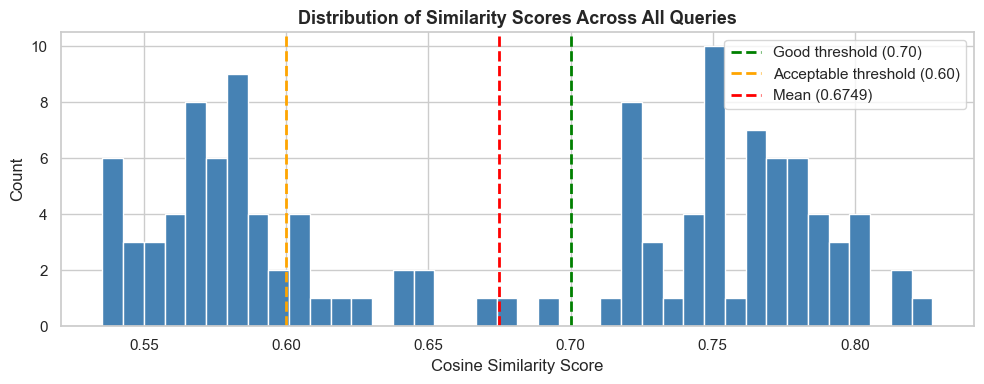

Mean similarity score: 0.6749
Median similarity score: 0.7194
% above 0.70 threshold: 50.8%
% above 0.60 threshold: 62.5%


In [20]:
all_scores = []
for test in test_queries:
    results = semantic_search(test['query'], top_k=20,
                              sentiment_filter=test['filter'])
    all_scores.extend(results['similarity_score'].tolist())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_scores, bins=40, color='steelblue', edgecolor='white')
ax.axvline(x=0.70, color='green', linestyle='--',
           linewidth=2, label='Good threshold (0.70)')
ax.axvline(x=0.60, color='orange', linestyle='--',
           linewidth=2, label='Acceptable threshold (0.60)')
ax.axvline(x=np.mean(all_scores), color='red', linestyle='--',
           linewidth=2, label=f'Mean ({np.mean(all_scores):.4f})')
ax.set_title('Distribution of Similarity Scores Across All Queries',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cosine Similarity Score')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean similarity score: {np.mean(all_scores):.4f}')
print(f'Median similarity score: {np.median(all_scores):.4f}')
print(f'% above 0.70 threshold: {(np.array(all_scores) >= 0.70).mean() * 100:.1f}%')
print(f'% above 0.60 threshold: {(np.array(all_scores) >= 0.60).mean() * 100:.1f}%')

## Business Insights and Recommendations

### How This System Creates Business Value

**For Product Managers:**  
Instead of reading 500 reviews after a product update, a PM can query *"what changed after the new formula"* and get an instant summary of relevant feedback. This compresses hours of manual review into seconds.

**For Customer Support Teams:**  
Support agents can query *"customers complaining about expiry dates"* to instantly understand the scope and nature of a recurring complaint before responding to tickets.

**For Marketing Teams:**  
Querying *"what do customers love most about this product"* surfaces authentic language that can directly inform ad copy and product descriptions.

**For Quality Assurance:**  
Filtering by negative sentiment and querying *"packaging broken damaged shipment"* automatically surfaces the most critical shipping complaints, enabling faster escalation to logistics teams.

### System Limitations and Production Considerations

| Consideration | Current State | Production Improvement |
|---|---|---|
| Corpus size | 100k reviews | Full 567k or real-time ingestion |
| Embeddings | Static, pre-computed | Incremental updates as new reviews arrive |
| Summarization | Extractive tendency | Fine-tune BART on domain-specific data |
| Latency | 30-60s on CPU | GPU deployment reduces to under 1 second |
| Evaluation | Similarity scores | Human evaluation for summary quality |


In [21]:
print('Notebook 04 complete.')
print(f'\nSystem Summary:')
print(f'  Retrieval corpus:     {len(df_retrieval):,} reviews')
print(f'  FAISS index vectors:  {index.ntotal:,}')
print(f'  Embedding dimension:  {dimension}')
print(f'  Test queries run:     {len(test_queries)}')
print(f'  Mean similarity:      {np.mean(all_scores):.4f}')
print(f'  Summarization model:  facebook/bart-large-cnn')

Notebook 04 complete.

System Summary:
  Retrieval corpus:     100,000 reviews
  FAISS index vectors:  100,000
  Embedding dimension:  384
  Test queries run:     6
  Mean similarity:      0.6749
  Summarization model:  facebook/bart-large-cnn
